<a href="https://colab.research.google.com/github/atikur234/BanglaOCR/blob/main/efficientnet_b0_ocr_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm




In [ ]:
# ======== Paths ========
BASE_DIR = r"D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")
MODEL_DIR = os.path.join(BASE_DIR, "EfficientNetB0-20epochs")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b0.pth")
PLOT_PATH = os.path.join(MODEL_DIR, "training_plot.png")
CM_PATH = os.path.join(MODEL_DIR, "confusion_matrix.png")
CSV_PATH = os.path.join(MODEL_DIR, "predictions.csv")

In [ ]:
# ======== Dataset ========
class BanglaOCRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        folders = sorted(os.listdir(root_dir), key=lambda x: int(x))
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path): continue
            label = int(folder) - 1
            for file in os.listdir(folder_path):
                if file.lower().endswith(".bmp"):
                    self.samples.append((os.path.join(folder_path, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, label, path

In [ ]:
# ======== Transform ========
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# ======== Data Loaders ========
full_train_set = BanglaOCRDataset(TRAIN_DIR, transform)
val_size = int(0.1 * len(full_train_set))
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(BanglaOCRDataset(TEST_DIR, transform), batch_size=64, shuffle=False)

In [ ]:
# ======== EfficientNet Model ========
def get_efficientnet_b0(num_classes=243):
    model = efficientnet_b0(weights=None)
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)  # grayscale
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

In [ ]:
# ======== EarlyStopping ========
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False
        self.best_model_state = None

    def check(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [ ]:
# ======== Training ========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_efficientnet_b0(num_classes=243).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopper = EarlyStopping()

EPOCHS = 20
train_losses, val_losses, train_accuracies = [], [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_losses.append(total_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.4f}")
    early_stopper.check(val_loss, model)
    if early_stopper.should_stop:
        print("🛑 Early stopping triggered.")
        break

Epoch 1: 100%|██████████| 709/709 [03:45<00:00,  3.15it/s]


Epoch 1 | Train Loss: 2691.2532 | Accuracy: 15.07% | Val Loss: 185.1891


Epoch 2: 100%|██████████| 709/709 [02:17<00:00,  5.17it/s]


Epoch 2 | Train Loss: 1182.8674 | Accuracy: 49.19% | Val Loss: 85.3405


Epoch 3: 100%|██████████| 709/709 [03:13<00:00,  3.66it/s]


...

Epoch 18 | Train Loss: 189.6995 | Accuracy: 87.20% | Val Loss: 29.1582


Epoch 19: 100%|██████████| 709/709 [01:28<00:00,  8.03it/s]


Epoch 19 | Train Loss: 188.4486 | Accuracy: 87.32% | Val Loss: 27.5221


Epoch 20: 100%|██████████| 709/709 [01:16<00:00,  9.32it/s]


Epoch 20 | Train Loss: 175.7980 | Accuracy: 87.88% | Val Loss: 29.6772


In [ ]:
# ======== Save Model ========
torch.save(early_stopper.best_model_state, MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

✅ Model saved to: D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset\EfficientNetB0-20epochs\efficientnet_b0.pth


📈 Plot saved to: D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset\EfficientNetB0-20epochs\training_plot.png


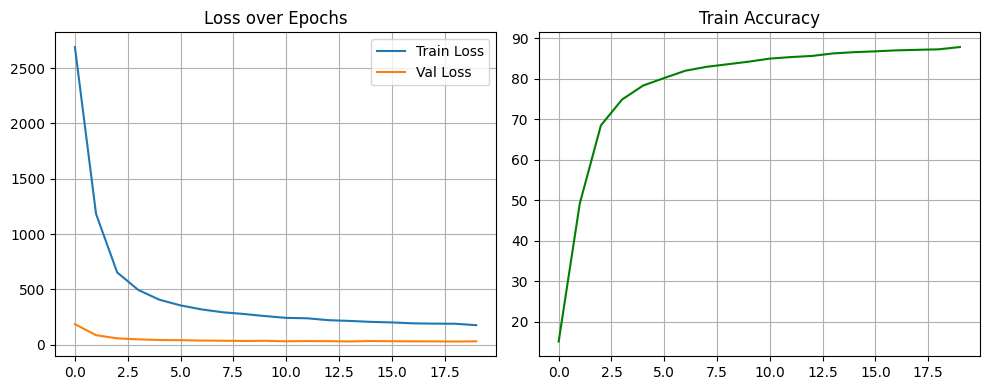

In [ ]:
# ======== Plotting ========
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss over Epochs")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", color="green")
plt.title("Train Accuracy")
plt.grid()

plt.tight_layout()
plt.savefig(PLOT_PATH)
print(f"📈 Plot saved to: {PLOT_PATH}")

In [ ]:
# ======== Testing ========
model.load_state_dict(early_stopper.best_model_state)
model.eval()
y_true, y_pred, paths = [], [], []

with torch.no_grad():
    for images, labels, img_paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
        paths.extend(img_paths)

Testing: 100%|██████████| 188/188 [01:52<00:00,  1.66it/s]


✅ Test Accuracy: 90.39%
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        52
           1       1.00      0.98      0.99        43
           2       0.77      1.00      0.87        49
           3       0.88      0.98      0.93        53
           4       0.96      0.96      0.96        51
           5       0.98      0.82      0.89        49
           6       0.87      0.80      0.84        51
           7       0.94      0.96      0.95        49
           8       1.00      1.00      1.00        25
           9       0.96      0.93      0.94        55
          10       0.94      0.94      0.94        51
          11       0.89      0.96      0.93        26
          12       0.92      0.93      0.93        61
          13       0.87      1.00      0.93        48
          14       1.00      0.97      0.98        32
          15       0.93      1.00      0.96        52
          16       1.00      0.9

C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

🧩 Confusion matrix saved to: D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset\EfficientNetB0-20epochs\confusion_matrix.png


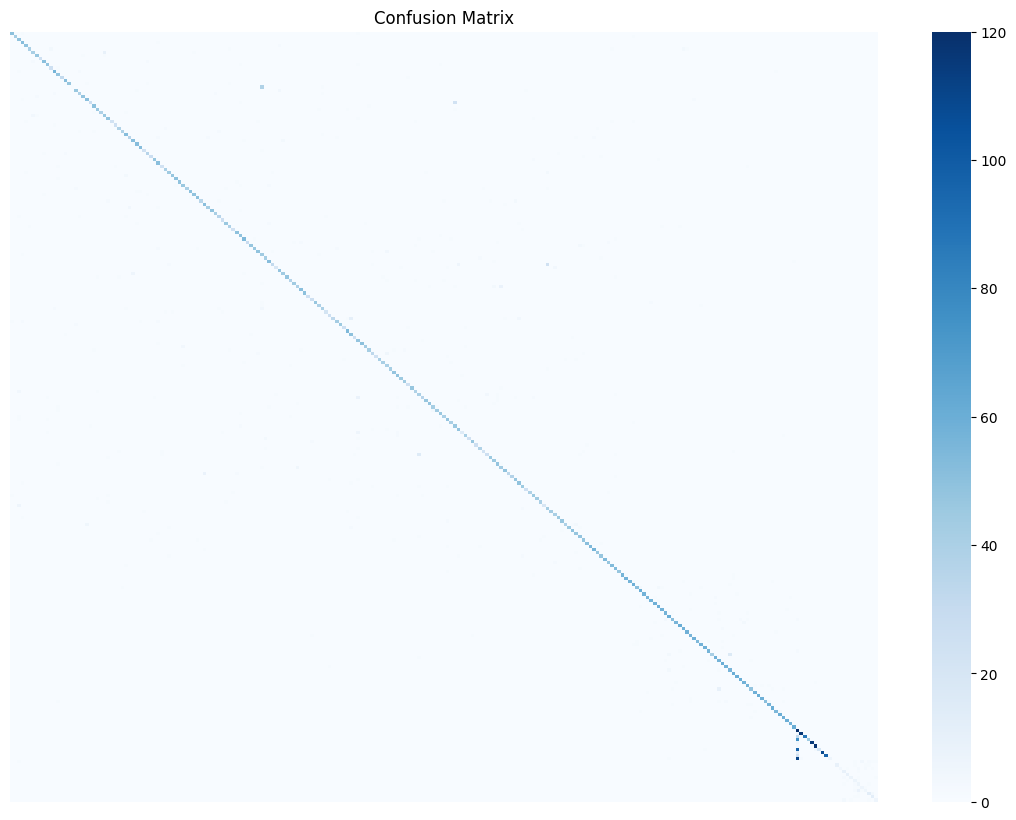

In [ ]:
# ======== Report & Confusion Matrix ========
acc = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {acc * 100:.2f}%")
print("📊 Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.savefig(CM_PATH)
print(f"🧩 Confusion matrix saved to: {CM_PATH}")

In [ ]:
# ======== Save CSV ========
df = pd.DataFrame({
    "image_path": paths,
    "actual": y_true,
    "predicted": y_pred
})
df.to_csv(CSV_PATH, index=False)
print(f"📄 Predictions saved to: {CSV_PATH}")

📄 Predictions saved to: D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset\EfficientNetB0-20epochs\predictions.csv
